In [20]:
import pandas as pd

file_path = "../data/raw/transaction.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (1000, 2)
  Transaction_ID                                            itemset
0             t1  ['Chicken', 'Vaseline Petroleum Jelly', 'Shamp...
1             t2  ['Conditioner', 'Fortune Sunlite Refined Oil',...
2             t3  ['Tomatoes', 'Milk', 'Soap', 'Vaseline Petrole...
3             t4  ['Milk', 'Shampoo', 'Juice', 'Toothpaste', 'Co...
4             t5  ['Milk', 'Conditioner', 'Toothpaste', 'Eggs', ...


In [21]:
import ast

transactions = df["itemset"].apply(ast.literal_eval).tolist()

print("Transactions prepared successfully!")
print("Number of transactions:", len(transactions))
print("First transaction:")
print(transactions[0])

Transactions prepared successfully!
Number of transactions: 1000
First transaction:
['Chicken', 'Vaseline Petroleum Jelly', 'Shampoo', 'Conditioner', 'MDH Chaat Masala', 'Eggs', 'Spinach', 'Fish', 'Ariel Liquid Detergent', 'Salt', 'Capsicum']


In [22]:
from mlxtend.preprocessing import TransactionEncoder

encoder = TransactionEncoder()

encoded_data = encoder.fit(transactions).transform(transactions)

basket_encoded = pd.DataFrame(
    encoded_data,
    columns=encoder.columns_
)

print("One-hot encoding completed successfully!")
print("Shape:", basket_encoded.shape)
print(basket_encoded.head())

One-hot encoding completed successfully!
Shape: (1000, 64)
   Almonds  Aloo Bhujia  Ariel Liquid Detergent  Ashirvaad Whole Wheat Atta  \
0    False        False                    True                       False   
1    False        False                   False                       False   
2    False        False                   False                       False   
3    False        False                   False                       False   
4    False        False                   False                       False   

   Balaji Masala Masti Chips  Bananas  Bedsheet Double Bed  Bread  Butter  \
0                      False    False                False  False   False   
1                      False    False                False  False    True   
2                      False    False                False  False    True   
3                      False    False                False   True   False   
4                      False    False                False  False   False   

   

In [23]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket_encoded,
    min_support=0.05,
    use_colnames=True
)

print("Frequent itemsets generated successfully!")
print("Number of frequent itemsets:", len(frequent_itemsets))
print(frequent_itemsets.head(10))

Frequent itemsets generated successfully!
Number of frequent itemsets: 896
   support                                 itemsets
0    0.076                     frozenset({Almonds})
1    0.076                 frozenset({Aloo Bhujia})
2    0.092      frozenset({Ariel Liquid Detergent})
3    0.083  frozenset({Ashirvaad Whole Wheat Atta})
4    0.087   frozenset({Balaji Masala Masti Chips})
5    0.084                     frozenset({Bananas})
6    0.093         frozenset({Bedsheet Double Bed})
7    0.519                       frozenset({Bread})
8    0.341                      frozenset({Butter})
9    0.545                    frozenset({Capsicum})


In [24]:
itemset_sizes = frequent_itemsets["itemsets"].apply(len)

print("Single-item itemsets:", (itemset_sizes == 1).sum())
print("Two-item itemsets:", (itemset_sizes == 2).sum())
print("Three-item itemsets:", (itemset_sizes == 3).sum())
print("Four-item itemsets:", (itemset_sizes == 4).sum())

Single-item itemsets: 64
Two-item itemsets: 222
Three-item itemsets: 554
Four-item itemsets: 56


In [25]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

print("Association rules generated successfully!")
print("Number of rules:", len(rules))

Association rules generated successfully!
Number of rules: 2077


In [26]:
top_rules = rules.sort_values(
    by="lift",
    ascending=False
).head(10)

print(top_rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]])

                                       antecedents               consequents  \
2075             frozenset({Tomatoes, Rice, Salt})         frozenset({Fish})   
192                  frozenset({Dettol Hand Wash})         frozenset({Milk})   
1873            frozenset({Capsicum, Bread, Eggs})    frozenset({Face Wash})   
204                         frozenset({Olive Oil})         frozenset({Eggs})   
1219               frozenset({Face Wash, Chicken})         frozenset({Milk})   
1276                 frozenset({Soap, Cornflakes})  frozenset({Conditioner})   
5          frozenset({Ashirvaad Whole Wheat Atta})  frozenset({Conditioner})   
2063      frozenset({Tomatoes, Capsicum, Shampoo})   frozenset({Toothpaste})   
715                frozenset({Cornflakes, Butter})         frozenset({Rice})   
2002  frozenset({Tomatoes, Capsicum, Conditioner})         frozenset({Soap})   

      support  confidence      lift  
2075    0.053    0.477477  1.360335  
192     0.051    0.653846  1.297314  
1873 

In [27]:
simple_rules = rules[
    (rules["antecedents"].apply(len) == 1) &
    (rules["consequents"].apply(len) == 1) &
    (rules["lift"] > 1)
].copy()

simple_rules = simple_rules.sort_values(
    by="lift",
    ascending=False
)

print("Useful 1-to-1 rules:", len(simple_rules))

print(simple_rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(15))

Useful 1-to-1 rules: 148
                                  antecedents               consequents  \
192             frozenset({Dettol Hand Wash})         frozenset({Milk})   
204                    frozenset({Olive Oil})         frozenset({Eggs})   
5     frozenset({Ashirvaad Whole Wheat Atta})  frozenset({Conditioner})   
263        frozenset({MTR Ready-to-Eat Poha})         frozenset({Rice})   
245                 frozenset({Fresh Apples})         frozenset({Rice})   
37                 frozenset({Organic Honey})        frozenset({Bread})   
295                      frozenset({Saffron})     frozenset({Tomatoes})   
243  frozenset({Fortune Sunlite Refined Oil})         frozenset({Salt})   
91   frozenset({Fortune Sunlite Refined Oil})     frozenset({Capsicum})   
194                 frozenset({Energy Drink})         frozenset({Eggs})   
193                 frozenset({Dove Shampoo})         frozenset({Salt})   
281                 frozenset({Pillow Cover})         frozenset({Salt})   


In [28]:
clean_rules = simple_rules.copy()

clean_rules["Product"] = clean_rules["antecedents"].apply(
    lambda x: next(iter(x))
)

clean_rules["Recommended_Product"] = clean_rules["consequents"].apply(
    lambda x: next(iter(x))
)

clean_rules["Support"] = clean_rules["support"].round(3)
clean_rules["Confidence"] = (clean_rules["confidence"] * 100).round(2)
clean_rules["Lift"] = clean_rules["lift"].round(2)

clean_rules = clean_rules[[
    "Product",
    "Recommended_Product",
    "Support",
    "Confidence",
    "Lift"
]]

print("Clean association rules:")
print(clean_rules.head(15))

Clean association rules:
                         Product Recommended_Product  Support  Confidence  \
192             Dettol Hand Wash                Milk    0.051       65.38   
204                    Olive Oil                Eggs    0.057       64.04   
5     Ashirvaad Whole Wheat Atta         Conditioner    0.050       60.24   
263        MTR Ready-to-Eat Poha                Rice    0.050       60.24   
245                 Fresh Apples                Rice    0.062       60.19   
37                 Organic Honey               Bread    0.053       63.86   
295                      Saffron            Tomatoes    0.050       65.79   
243  Fortune Sunlite Refined Oil                Salt    0.054       61.36   
91   Fortune Sunlite Refined Oil            Capsicum    0.058       65.91   
194                 Energy Drink                Eggs    0.050       60.24   
193                 Dove Shampoo                Salt    0.051       60.71   
281                 Pillow Cover                Sal

In [29]:
output_path = "../outputs/results/association_rules.csv"

clean_rules.to_csv(output_path, index=False)

print("Association rules saved successfully!")
print("File:", output_path)
print("Total rules saved:", len(clean_rules))

Association rules saved successfully!
File: ../outputs/results/association_rules.csv
Total rules saved: 148


In [30]:
print("Total association rules:", len(clean_rules))

print("\nTop 10 cross-selling recommendations:")
print(clean_rules.head(10))

Total association rules: 148

Top 10 cross-selling recommendations:
                         Product Recommended_Product  Support  Confidence  \
192             Dettol Hand Wash                Milk    0.051       65.38   
204                    Olive Oil                Eggs    0.057       64.04   
5     Ashirvaad Whole Wheat Atta         Conditioner    0.050       60.24   
263        MTR Ready-to-Eat Poha                Rice    0.050       60.24   
245                 Fresh Apples                Rice    0.062       60.19   
37                 Organic Honey               Bread    0.053       63.86   
295                      Saffron            Tomatoes    0.050       65.79   
243  Fortune Sunlite Refined Oil                Salt    0.054       61.36   
91   Fortune Sunlite Refined Oil            Capsicum    0.058       65.91   
194                 Energy Drink                Eggs    0.050       60.24   

     Lift  
192  1.30  
204  1.28  
5    1.25  
263  1.24  
245  1.24  
37   1.23  


In [31]:
import joblib

model_path = "../models/association/apriori_rules.pkl"

joblib.dump(clean_rules, model_path)

print("Apriori model artifact saved successfully!")
print("File:", model_path)

Apriori model artifact saved successfully!
File: ../models/association/apriori_rules.pkl


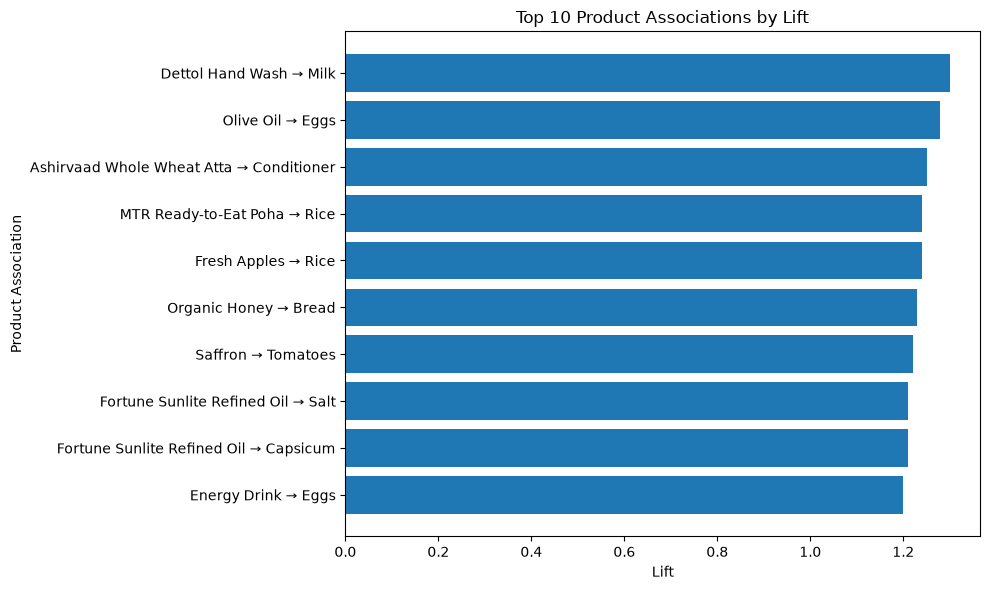

In [32]:
import matplotlib.pyplot as plt

top_lift = clean_rules.sort_values(
    by="Lift",
    ascending=False
).head(10)

labels = (
    top_lift["Product"]
    + " → "
    + top_lift["Recommended_Product"]
)

plt.figure(figsize=(10, 6))

plt.barh(labels, top_lift["Lift"])
plt.xlabel("Lift")
plt.ylabel("Product Association")
plt.title("Top 10 Product Associations by Lift")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "../outputs/figures/apriori_top_lift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

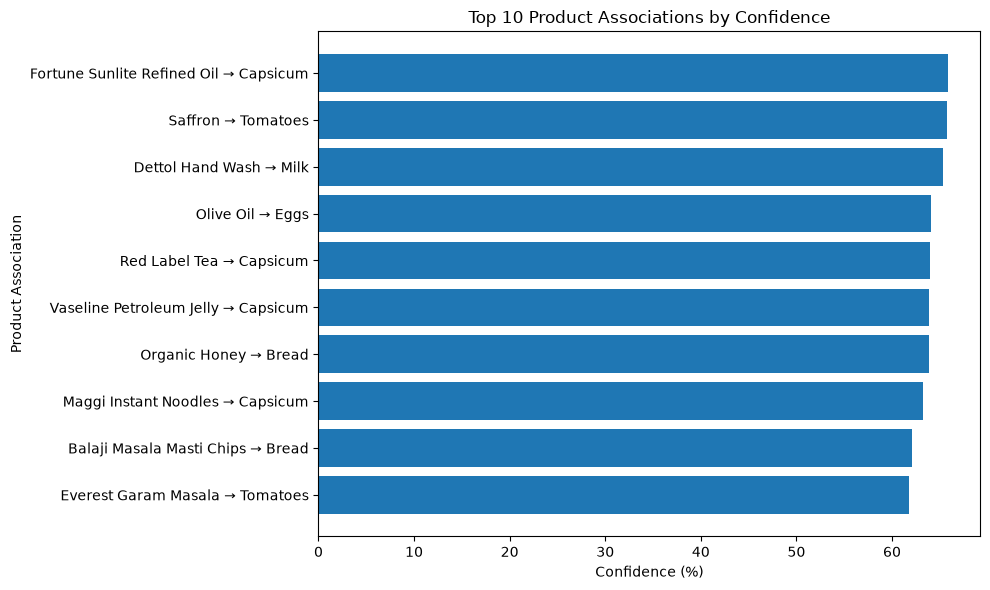

In [33]:
top_confidence = clean_rules.sort_values(
    by="Confidence",
    ascending=False
).head(10)

labels = (
    top_confidence["Product"]
    + " → "
    + top_confidence["Recommended_Product"]
)

plt.figure(figsize=(10, 6))

plt.barh(labels, top_confidence["Confidence"])
plt.xlabel("Confidence (%)")
plt.ylabel("Product Association")
plt.title("Top 10 Product Associations by Confidence")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "../outputs/figures/apriori_top_confidence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()